# 📚 Corrective Retrieval-Augmented Generation (CRAG)

## Introduction

Retrieval-Augmented Generation (RAG) enhances Large Language Models (LLMs) by retrieving relevant information from an external knowledge base before generating a response. Instead of relying solely on the model's internal knowledge, RAG grounds its responses using retrieved documents, reducing hallucinations and improving factual accuracy.

In a traditional RAG pipeline, the system retrieves documents from a vector database and directly passes them to the LLM for answer generation. This works well when retrieval is successful, but it assumes the retrieved documents are always relevant and sufficient to answer the user's question.

In practice, retrieved documents may be irrelevant, incomplete, or noisy. Passing such context directly to the LLM often results in inaccurate or hallucinated responses.

**Corrective Retrieval-Augmented Generation (CRAG)** improves upon traditional RAG by introducing a **retrieval evaluation stage** before answer generation. The retrieved documents are first evaluated for relevance. Depending on the evaluation result, the workflow either:

- Refines the retrieved knowledge and generates an answer.
- Rewrites the user's query, performs a web search, and uses external knowledge when local retrieval is insufficient.

This evaluate-then-correct strategy makes the system more robust than a standard RAG pipeline.

---

# Traditional RAG Workflow

```text
                    User Question
                          │
                          ▼
                Retrieve Documents
                          │
                          ▼
                 Retrieved Documents
                          │
                          ▼
                 Large Language Model
                          │
                          ▼
                    Final Answer
```

## Limitations

- Assumes retrieved documents are always relevant.
- Cannot detect retrieval failures.
- Uses retrieved chunks without validating their quality.
- Produces hallucinations when retrieval quality is poor.
- Limited to the local knowledge base.

---

# Corrective RAG Workflow (Implemented)

```text
                     User Question
                           │
                           ▼
                Retrieve Documents
                           │
                           ▼
             Evaluate Retrieved Documents
                           │
                  ┌────────┴────────┐
                  │                 │
             Relevant         Not Relevant
                  │                 │
                  ▼                 ▼
        Knowledge Refinement   Rewrite Query
                  │                 │
                  │                 ▼
                  │           Web Search
                  │                 │
                  └─────────┬───────┘
                            ▼
                 Generate Final Answer
```

---

# How This Implementation Improves Traditional RAG

This notebook implements a simplified CRAG workflow.

### If retrieved documents are relevant

1. Retrieved documents are evaluated.
2. Relevant context is refined by filtering unnecessary information.
3. The refined context is passed to the LLM.
4. The LLM generates the final answer.

### If retrieved documents are not relevant

1. The original user question is preserved.
2. The query is rewritten into a web-search-friendly query.
3. A web search is performed using the rewritten query.
4. Retrieved web information becomes the context.
5. The LLM generates the final answer using the web context.

Unlike traditional RAG, this workflow does not blindly trust retrieved documents. Instead, it attempts to recover from retrieval failures using query rewriting and external search.

---

# Traditional RAG vs Corrective RAG

| Feature | Traditional RAG | This CRAG Implementation |
|----------|-----------------|---------------------------|
| Retrieve documents | ✅ | ✅ |
| Evaluate retrieved context | ❌ | ✅ |
| Knowledge refinement | ❌ | ✅ |
| Query rewriting | ❌ | ✅ |
| Web search fallback | ❌ | ✅ |
| Dynamic decision making | ❌ | ✅ |
| Handles poor retrieval | ❌ | ✅ |
| Reduces hallucinations | Moderate | Better |
| External knowledge support | ❌ | ✅ |

---

# Technologies Used

This notebook uses the following technologies:

- **LangChain** – Document loading, prompts, retrieval, and chains.
- **LangGraph** – Workflow orchestration using graph-based execution.
- **ChromaDB** – Vector database for semantic document retrieval.
- **HuggingFace Embeddings** (`sentence-transformers/all-MiniLM-L6-v2`) – Text embeddings.
- **Groq LLM** *(configurable through `MODEL_NAME`)* – Retrieval grading, query rewriting, and answer generation.
- **Tavily Web Search** – External information retrieval when local knowledge is insufficient.

---

# Goal of this Notebook

In this notebook we build a simplified Corrective Retrieval-Augmented Generation (CRAG) pipeline using the **Attention Is All You Need** research paper as the primary knowledge source.

The workflow consists of the following stages:

1. Load and index the research paper into ChromaDB.
2. Retrieve relevant document chunks.
3. Evaluate whether the retrieved context is relevant.
4. If relevant, refine the retrieved context.
5. If not relevant, rewrite the query and perform a web search.
6. Generate the final answer using the best available context.

This notebook demonstrates how retrieval evaluation, knowledge refinement, query rewriting, and web-search fallback can make Retrieval-Augmented Generation systems more reliable than traditional RAG.

In [1]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("./data/attention.pdf")
documents = loader.load()
print(len(documents))



C:\Users\DELL\AppData\Local\Temp\ipykernel_17200\4129469998.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
d:\AI-ML\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


15


In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(documents)
print(len(chunks))

52


In [3]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1982.13it/s]


In [4]:
from langchain_chroma import Chroma

vectorstore = Chroma.from_documents(
    chunks,
    embeddings,
    persist_directory="chroma_db"
)


In [5]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3},
    search_type="similarity"
)

In [6]:
query = "Who are the authors of Attention Is All You Need?"

docs = retriever.invoke(query)

for i, doc in enumerate(docs, start=1):
    print(f"\nDocument {i}")
    print("-" * 50)
    print(doc.page_content)


Document 1
--------------------------------------------------
3.2 Attention
An attention function can be described as mapping a query and a set of key-value pairs to an output,
where the query, keys, values, and output are all vectors. The output is computed as a weighted sum
3

Document 2
--------------------------------------------------
Attention Visualizations
Input-Input Layer5
It
is
in
this
spirit
that
a
majority
of
American
governments
have
passed
new
laws
since
2009
making
the
registration
or
voting
process
more
difficult
.
<EOS>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
It
is
in
this
spirit
that
a
majority
of
American
governments
have
passed
new
laws
since
2009
making
the
registration
or
voting
process
more
difficult
.
<EOS>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
Figure 3: An example of the attention mechanism following long-distance dependencies in the
encoder self-attention in layer 5 of 6. Many of the attention heads attend to a distant dependency of
the verb ‘making’, completing t

In [7]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

if not os.getenv("GROQ_API_KEY"):
    raise ValueError(
        "GROQ_API_KEY not found. Please add it to your .env file."
    )

MODEL_NAME = os.getenv(
    "MODEL_NAME",
    "llama-3.3-70b-versatile"
)

llm = ChatGroq(
    model=MODEL_NAME,
    temperature=0
)

print(f"Using model: {MODEL_NAME}")

Using model: openai/gpt-oss-20b


In [8]:

# NORMAL RAG (baseline, no correction)
from langchain_core.prompts import ChatPromptTemplate
from typing import List, TypedDict
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser


rag_prompt = ChatPromptTemplate.from_template(
    """You are an assistant answering questions about the "Attention Is All You Need" paper.
Use only the provided context to answer. If the context doesn't contain the answer, say so.

Context:
{context}

Question: {question}

Answer:"""
)

def format_docs(docs: List[Document]) -> str:
    return "\n\n".join(d.page_content for d in docs)

normal_rag_chain = (
    {"context": retriever | format_docs, "question": lambda x: x}
    | rag_prompt
    | llm
    | StrOutputParser()
)

# Test
print(normal_rag_chain.invoke("What is multi-head attention?"))

**Multi‑head attention** is a way of computing attention that lets the model look at the input from several different “sub‑spaces” at the same time.  
In the Transformer, each head performs a standard scaled‑dot‑product attention on a projected version of the queries, keys and values:

\[
\text{head}_i = \text{Attention}\bigl(QW_{Q_i},\; KW_{K_i},\; VW_{V_i}\bigr)
\]

where \(W_{Q_i}, W_{K_i}, W_{V_i}\) are learned projection matrices.  
The outputs of all \(h\) heads are concatenated and then linearly projected again:

\[
\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1,\dots,\text{head}_h)\,W_O .
\]

In the paper the authors use \(h=8\) heads, each with dimension \(d_k = d_v = d_{\text{model}}/h = 64\).  
Because each head works on a reduced dimension, the overall computational cost is roughly the same as a single‑head attention with full dimensionality, but the model can jointly attend to information from different representation subspaces at different positions.


In [9]:

# Retrieval Grader — grades each retrieved doc as relevant/not
from pydantic import BaseModel, Field

class GradeDocument(BaseModel):
    """Binary relevance grade for a retrieved document."""
    binary_score: str = Field(
        description="Is the document relevant to the question? 'yes' or 'no'"
    )

grade_llm = llm.with_structured_output(GradeDocument)

grade_prompt = ChatPromptTemplate.from_template(
    """You are a grader assessing relevance of a retrieved document to a user question.
If the document contains keywords or semantic meaning related to the question, grade it as relevant.
This is a lenient filter meant only to catch clearly irrelevant retrievals.

Retrieved document:
{document}

User question: {question}

Give a binary score 'yes' or 'no'."""
)

retrieval_grader = grade_prompt | grade_llm

In [10]:

# Query Rewriter — rewrites question for web search

rewrite_prompt = ChatPromptTemplate.from_template(
    """You are a query rewriter that converts an input question into a better,
web-search-optimized version. Look at the input and reason about the underlying
semantic intent.

Original question: {question}

Rewritten question (just the question, nothing else):"""
)

question_rewriter = rewrite_prompt | llm | StrOutputParser()

In [11]:
# Web search tool (fallback when docs are irrelevant)
from langchain_tavily import TavilySearch
web_search_tool = TavilySearch(k=3)

In [12]:

# Generation chain (reused after correction)
generate_chain = (
    rag_prompt
    | llm
    | StrOutputParser()
)

In [13]:
# CRAG State definition
class CRAGState(TypedDict):

    question: str                # original user question

    rewritten_question: str      # rewritten query

    generation: str

    web_search_needed: str

    documents: List[Document]

In [14]:

# Graph nodes

def retrieve(state: CRAGState):
    print("---RETRIEVE---")
    question = state["question"]
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def grade_documents(state: CRAGState):
    print("---GRADE DOCUMENTS---")
    question = state["question"]
    documents = state["documents"]

    filtered_docs = []
    web_search_needed = False

    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score.lower().strip()
        if grade == "yes":
            print("---GRADE: RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: NOT RELEVANT---")

    # If too few relevant docs survive, trigger web search correction
    if len(filtered_docs) == 0:
        web_search_needed = True

    return {
        "documents": filtered_docs,
        "question": question,
        "web_search_needed": web_search_needed
    }


def transform_query(state: CRAGState):

    print("---TRANSFORM QUERY---")

    original_question = state["question"]

    rewritten_question = question_rewriter.invoke(
        {"question": original_question}
    )

    return {
        "question": original_question,
        "rewritten_question": rewritten_question,
        "documents": state["documents"]
    }

def web_search(state: CRAGState):

    print("---WEB SEARCH---")

    rewritten_question = state["rewritten_question"]

    documents = state["documents"]

    try:
        response = web_search_tool.invoke(
            {"query": rewritten_question}
        )

        search_results = response.get("results", [])

    except Exception as e:

        print(f"Web Search Error: {e}")

        search_results = []

    web_contents = []

    for result in search_results:

        content = result.get("content")

        if content:
            web_contents.append(content)

    if web_contents:

        web_doc = Document(
            page_content="\n\n".join(web_contents)
        )

        documents.append(web_doc)

    else:

        print("---NO WEB RESULTS FOUND---")

    return {

        "documents": documents,

        "question": state["question"],

        "rewritten_question": rewritten_question

    }
def generate(state: CRAGState):
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    context = format_docs(documents)
    generation = generate_chain.invoke({"context": context, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def decide_to_generate(state: CRAGState):
    print("---DECISION---")
    if state["web_search_needed"]:
        print("---DOCS NOT RELEVANT -> TRANSFORM QUERY + WEB SEARCH---")
        return "transform_query"
    else:
        print("---DOCS RELEVANT -> GENERATE---")
        return "generate"

In [15]:

#  Build the CRAG graph
from langgraph.graph import StateGraph,START,END


workflow = StateGraph(CRAGState)

workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("transform_query", transform_query)
workflow.add_node("web_search", web_search)
workflow.add_node("generate", generate)

workflow.set_entry_point("retrieve")
workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)

workflow.add_edge("transform_query", "web_search")
workflow.add_edge("web_search", "generate")
workflow.add_edge("generate", END)

crag_app = workflow.compile()

In [16]:
# Run CRAG
question = "What are transformers?"

result = crag_app.invoke({"question": question})

print("\n=== FINAL ANSWER ===")
print(result["generation"])

---RETRIEVE---
---GRADE DOCUMENTS---
---GRADE: RELEVANT---
---GRADE: RELEVANT---
---GRADE: RELEVANT---
---DECISION---
---DOCS RELEVANT -> GENERATE---
---GENERATE---

=== FINAL ANSWER ===
Transformers are a neural network architecture that replaces recurrence with attention mechanisms to capture global dependencies between input and output.  
- The model is built as an encoder‑decoder stack (Figure 1).  
- The encoder consists of \(N=6\) identical layers, each with a multi‑head self‑attention sub‑layer followed by a position‑wise fully‑connected feed‑forward network.  
- The decoder also uses stacked layers, each containing a masked self‑attention sub‑layer (so each position can attend only to itself and earlier positions) and an encoder‑decoder attention sub‑layer that lets decoder positions attend to all encoder positions.  
- All sub‑layers use residual connections and layer‑normalization, and every component outputs vectors of dimension \(d_{\text{model}}=512\).  
- Because the arch

In [17]:
# Example that triggers web search

question = "Who won the FIFA World Cup 2022?"

result = crag_app.invoke(
    {"question": question}
)

print(result["generation"])

---RETRIEVE---
---GRADE DOCUMENTS---
---GRADE: NOT RELEVANT---
---GRADE: NOT RELEVANT---
---GRADE: NOT RELEVANT---
---DECISION---
---DOCS NOT RELEVANT -> TRANSFORM QUERY + WEB SEARCH---
---TRANSFORM QUERY---
---WEB SEARCH---
---GENERATE---
Argentina won the FIFA World Cup 2022.


In [18]:
from pprint import pprint

results = web_search_tool.invoke({"query": "Who won the FIFA World Cup 2022?"})

print(type(results))
pprint(results)

<class 'dict'>
{'answer': None,
 'follow_up_questions': None,
 'images': [],
 'query': 'Who won the FIFA World Cup 2022?',
 'request_id': '0c5c542f-acaf-425f-97f2-e082511fe360',
 'response_time': 1.49,
 'results': [{'content': 'The final match of the 2022 FIFA World Cup, the 22nd '
                         "edition of FIFA's competition for men's national "
                         'football teams, was played at Lusail Stadium in '
                         'Lusail, Qatar, on 18 December 2022 (Qatari National '
                         'Day "National Day (Qatar)")), and was contested by '
                         'Argentina and defending champions France. They then '
                         'beat Australia 2–1 in the round of 16, the '
                         'Netherlands in the quarter-final through a penalty '
                         'shoot-out "Penalty shoot-out (association '
                         'football)") after it ended 2–2 in extra time, and '
                         'C

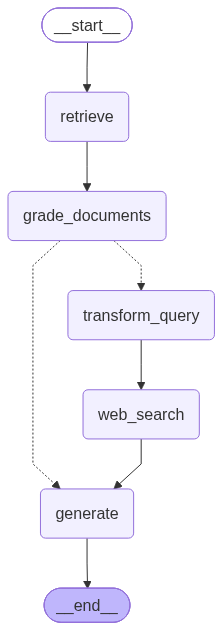

In [19]:

# Visualize the graph
from IPython.display import Image, display
display(Image(crag_app.get_graph().draw_mermaid_png()))